✅ STEP 1: Mount Google Drive


In [1]:
# from google.colab import drive
# drive.mount('/gdrive')


✅ STEP 2: Install Dependencies & Import Libraries

In [2]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models


In [3]:
# import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


PyTorch version: 2.5.1+cu121
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


✅ STEP 3: Set Device (CPU or GPU)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


✅ STEP 4: Prepare Dataset (TrashNet)
📦 Place your extracted TrashNet dataset in this folder inside your Google Drive:

Make sure the directory structure is like:


TrashNet/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/

Now use this code:


In [5]:
# data_dir = '/gdrive/MyDrive/WasteDatasets/TrashNet'
data_dir = r"E:\Paper\DatsetAll\Dataset4(shubhamdivakar)"

classes = os.listdir(data_dir)
print("Classes:", classes)

transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

dataset = ImageFolder(data_dir, transform=transform)
print(f"Total images: {len(dataset)}")


Classes: ['Organic', 'Recyclable']
Total images: 25077


In [6]:
from collections import Counter

# This gives the class indices
class_counts = Counter([dataset.targets[i] for i in range(len(dataset))])

# Print nicely with class names
for i, class_name in enumerate(dataset.classes):
    print(f"{class_name:10s}: {class_counts[i]} images")


Organic   : 13966 images
Recyclable: 11111 images


✅ STEP 5: Show a Sample Image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Label: Organic


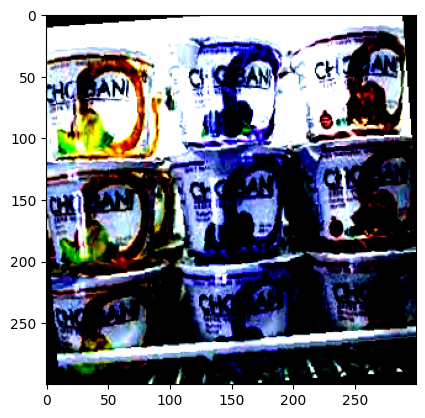

In [7]:
def show_sample(img, label):
    print("Label:", dataset.classes[label])
    plt.imshow(img.permute(1, 2, 0))

img, label = dataset[90]
show_sample(img, label)


✅ STEP 6: Split Dataset

We'll split it into train, validation, and test sets (e.g., 70-10-20):

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from torch.utils.data import Subset

random_seed = 42
torch.manual_seed(random_seed)

# Get original class labels
targets = [label for _, label in dataset]
targets_np = np.array(targets)

# Stratified split: 70% train, 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=random_seed)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets_np)), targets_np))

# From the 30% temp, split into val (10%) and test (20%)
temp_targets = targets_np[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=2/3, random_state=random_seed)
val_idx, test_idx = next(sss2.split(np.zeros(len(temp_targets)), temp_targets))

# Map val and test idx back to original
val_idx = np.array(temp_idx)[val_idx]
test_idx = np.array(temp_idx)[test_idx]

# Create subsets
train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)
test_ds = Subset(dataset, test_idx)

print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)} | Test size: {len(test_ds)}")


Train size: 17553 | Val size: 2508 | Test size: 5016


✅ STEP 7: DataLoaders

In [9]:
batch_size = 16

train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size=batch_size*2, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=batch_size*2, num_workers=2, pin_memory=True)


✅ STEP 8: Define Accuracy and Base Model Class



In [10]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print(f"Epoch [{epoch+1}], train_loss: {result['train_loss']:.4f}, "
              f"val_loss: {result['val_loss']:.4f}, val_acc: {result['val_acc']:.4f}")


✅ STEP 9: Define Improved Custom CNN Model (Model 1)


In [11]:
class ImprovedCNN(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 37 * 37, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, len(dataset.classes))
        )

    def forward(self, xb):
        return self.network(xb)

model = ImprovedCNN()


✅ STEP 10: Move Model and Data to GPU (if available)



In [12]:
def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

model = to_device(model, device)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)


✅ STEP 11: Train & Evaluate Functions



In [13]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(
    model, train_loader, val_loader,
    max_epochs=50,
    lr=1e-4,
    patience=5,
    opt_func=torch.optim.Adam,
    model_path="best_model.pth"
):
    history = []
    optimizer = opt_func(model.parameters(), lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # Evaluate on validation set
        result = evaluate(model, val_loader)
        val_loss = result['val_loss']
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)

        # Early Stopping + Save Best Model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save({"state_dict": model.state_dict()}, model_path)
            print(f"✅ Best model saved at: {model_path} (Epoch {epoch+1})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    print(f"Training stopped. Best epoch: {best_epoch+1} with val_loss: {best_val_loss:.4f}")
    return history


✅ STEP 12: Train the Model


In [ ]:
model_path = r"E:\Paper\Trained Models\Datset4_Models\improved_cnn_shubham.pth"
history = fit(model, train_dl, val_dl, max_epochs=50, lr=1e-4, patience=5, model_path=model_path)


Epoch [1], train_loss: 0.4910, val_loss: 0.4075, val_acc: 0.8278
✅ Best model saved at: E:\Paper\Trained Models\Datset4_Models\model_cnn.pth (Epoch 1)
Epoch [2], train_loss: 0.4141, val_loss: 0.3679, val_acc: 0.8509
✅ Best model saved at: E:\Paper\Trained Models\Datset4_Models\model_cnn.pth (Epoch 2)
Epoch [3], train_loss: 0.3905, val_loss: 0.4019, val_acc: 0.8344
Epoch [4], train_loss: 0.3771, val_loss: 0.3485, val_acc: 0.8532
✅ Best model saved at: E:\Paper\Trained Models\Datset4_Models\model_cnn.pth (Epoch 4)
Epoch [5], train_loss: 0.3759, val_loss: 0.3539, val_acc: 0.8561
Epoch [6], train_loss: 0.3604, val_loss: 0.3421, val_acc: 0.8596
✅ Best model saved at: E:\Paper\Trained Models\Datset4_Models\model_cnn.pth (Epoch 6)
Epoch [7], train_loss: 0.3518, val_loss: 0.3478, val_acc: 0.8581
Epoch [8], train_loss: 0.3448, val_loss: 0.3454, val_acc: 0.8631
Epoch [9], train_loss: 0.3409, val_loss: 0.3491, val_acc: 0.8577
Epoch [10], train_loss: 0.3360, val_loss: 0.3353, val_acc: 0.8675
✅ Bes

✅ STEP 14: Evaluate on Test Set


In [15]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for data in test_dl:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Test Accuracy: {:.2f}%'.format(100 * correct / total))


Test Accuracy: 88.16%


✅ STEP 13: Plot Accuracy and Loss



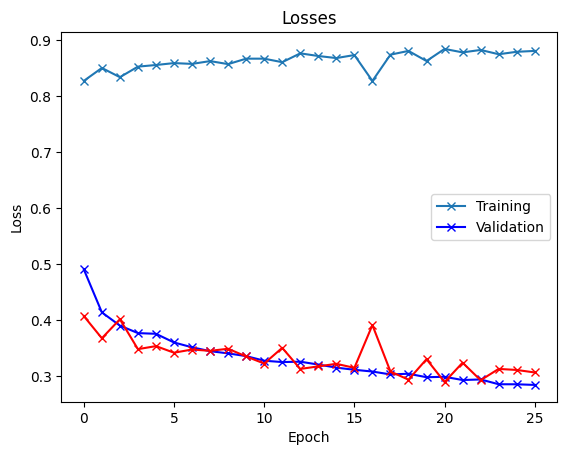

In [16]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Losses')

plot_accuracies(history)
plot_losses(history)


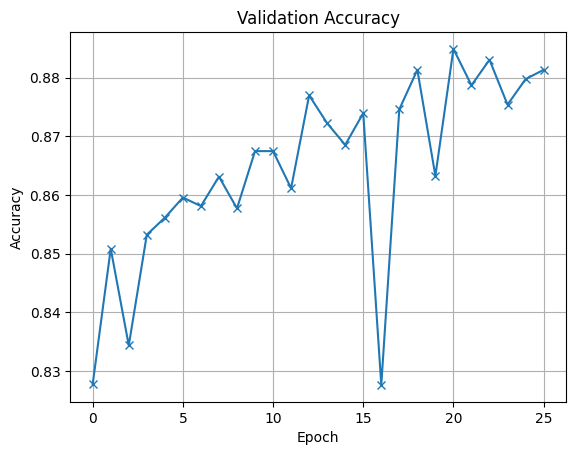

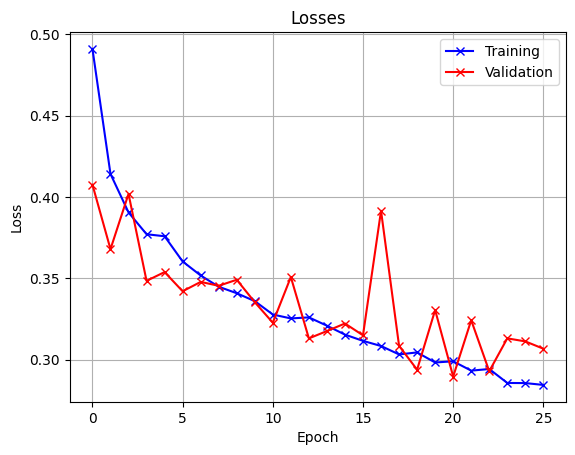

In [17]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.grid(True)
    plt.show()

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Losses')
    plt.grid(True)
    plt.show()

# Call them
plot_accuracies(history)
plot_losses(history)


✅ STEP 14: Evaluate on Test Set

We'll test the model’s accuracy on unseen images.

✅ STEP 15: Class-wise Accuracy

In [18]:
class_correct = list(0. for i in range(len(dataset.classes)))
class_total = list(0. for i in range(len(dataset.classes)))

with torch.no_grad():
    for data in test_dl:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(len(dataset.classes)):
    acc = 100 * class_correct[i] / class_total[i]
    print(f'Accuracy of {dataset.classes[i]:10s} : {acc:.2f}%')


Accuracy of Organic    : 89.76%
Accuracy of Recyclable : 86.28%


✅ STEP 16: Predict Single Image from Test Set

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7859696].


Label: Recyclable | Predicted: Recyclable


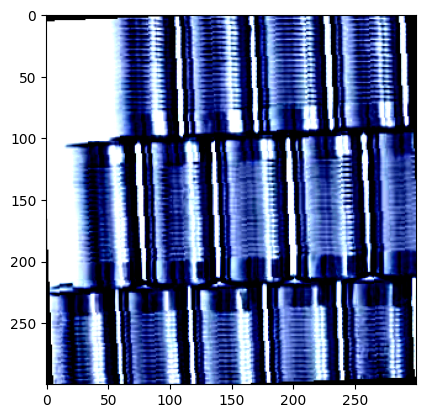

In [19]:
def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return dataset.classes[preds[0].item()]

img, label = test_ds[10]
plt.imshow(img.permute(1, 2, 0))
print("Label:", dataset.classes[label], "| Predicted:", predict_image(img, model))


✅ STEP 17: Save the Trained Model

✅ Model 1 (Improved CNN) is now fully done: trained, tested, and saved.



✅ 1. Confusion Matrix for CNN


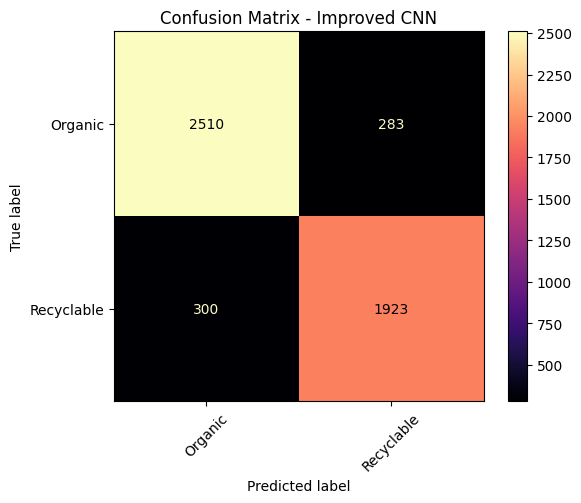

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn_preds = []
cnn_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_dl:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        cnn_preds.extend(preds.cpu().numpy())
        cnn_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(cnn_labels, cnn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap='magma', xticks_rotation=45)
plt.title("Confusion Matrix - Improved CNN")
plt.show()


✅ ✅ STEP 1: Evaluate Model 1 (Improved CNN)


In [34]:
def evaluate_model(model, dataloader):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

cnn_test_acc = evaluate_model(model, test_dl)
print("Custom CNN Test Accuracy: {:.2f}%".format(cnn_test_acc))

Custom CNN Test Accuracy: 87.90%


✅ 2. Per-Class Accuracy Bar Plot for CNN


C:\Users\Asus\AppData\Local\Temp\ipykernel_18460\3413408158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset.classes, y=cnn_class_acc, palette="crest")


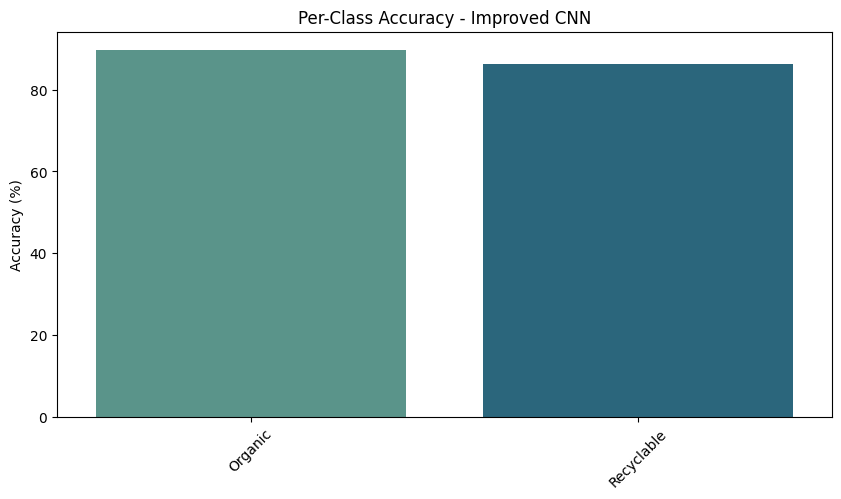

In [22]:
import seaborn as sns

cnn_class_acc = [100 * class_correct[i] / class_total[i] for i in range(len(dataset.classes))]

plt.figure(figsize=(10,5))
sns.barplot(x=dataset.classes, y=cnn_class_acc, palette="crest")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy - Improved CNN")
plt.xticks(rotation=45)
plt.show()


🔜 NEXT: Model 2 – ResNet-50 (Transfer Learning)


✅ STEP 1: Load Pretrained ResNet-50

We’ll replace the final layer to fit our waste classification classes.




In [23]:
class ResNetWasteClassifier(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = models.resnet50(pretrained=True)
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset.classes))

    def forward(self, xb):
        return self.network(xb)

resnet_model = ResNetWasteClassifier()
resnet_model = to_device(resnet_model, device)


c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ STEP 2: Evaluate Untrained ResNet-50



In [24]:
def validation_step(self, batch):
    images, labels = batch
    out = self(images)
    loss = F.cross_entropy(out, labels)
    try:
        acc = accuracy(out, labels)
    except TypeError:
        # fallback if accuracy is a float, not a function
        _, preds = torch.max(out, dim=1)
        acc = torch.tensor(torch.sum(preds == labels).item() / len(preds))
    return {'val_loss': loss.detach(), 'val_acc': acc}


✅ STEP 3: Train the ResNet-50 Model
We’ll use the same fit() function and optimizer (Adam).

<!-- Epoch [1], train_loss: 0.2002, val_loss: 0.1281, val_acc: 0.9557
Epoch [2], train_loss: 0.1331, val_loss: 0.1295, val_acc: 0.9490
Epoch [3], train_loss: 0.1080, val_loss: 0.1139, val_acc: 0.9628
Epoch [4], train_loss: 0.0873, val_loss: 0.1260, val_acc: 0.9581
Epoch [5], train_loss: 0.0662, val_loss: 0.1099, val_acc: 0.9593
Epoch [6], train_loss: 0.0573, val_loss: 0.1101, val_acc: 0.9672
Epoch [7], train_loss: 0.0530, val_loss: 0.1727, val_acc: 0.9519
Epoch [8], train_loss: 0.0446, val_loss: 0.1442, val_acc: 0.9561
Epoch [9], train_loss: 0.0441, val_loss: 0.1477, val_acc: 0.9577
Epoch [10], train_loss: 0.0358, val_loss: 0.1308, val_acc: 0.9628 -->
<!-- Epoch [11], train_loss: 0.0368, val_loss: 0.1491, val_acc: 0.9589
Epoch [12], train_loss: 0.0358, val_loss: 0.1398, val_acc: 0.9612
Epoch [13], train_loss: 0.0311, val_loss: 0.1470, val_acc: 0.9612
Epoch [14], train_loss: 0.0268, val_loss: 0.1225, val_acc: 0.9664
Epoch [15], train_loss: 0.0257, val_loss: 0.1341, val_acc: 0.9620
Epoch [16], train_loss: 0.0252, val_loss: 0.1740, val_acc: 0.9573
Epoch [17], train_loss: 0.0257, val_loss: 0.1310, val_acc: 0.9660
Epoch [18], train_loss: 0.0250, val_loss: 0.1678, val_acc: 0.9597
Epoch [19], train_loss: 0.0295, val_loss: 0.1298, val_acc: 0.9648
Epoch [20], train_loss: 0.0198, val_loss: 0.1349, val_acc: 0.9645 -->

In [27]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(
    model, train_loader, val_loader,
    max_epochs=50,
    lr=1e-4,
    patience=5,
    opt_func=torch.optim.Adam,
    model_path="best_resnet_model.pth"
):
    history = []
    optimizer = opt_func(model.parameters(), lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        val_loss = result['val_loss']
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)

        # Early stopping and save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({"state_dict": model.state_dict()}, model_path)
            print(f"✅ Best model saved at epoch {epoch+1}: {model_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                break

    return history


In [ ]:
resnet_path = r"E:\Paper\Trained Models\Datset4_Models\restnet50_shubham.pth"

resnet_history = fit(
    model=resnet_model,
    train_loader=train_dl,
    val_loader=val_dl,
    max_epochs=50,
    lr=3e-5,
    patience=5,
    model_path=resnet_path
)

print("Training complete. Best ResNet-50 model saved at:", resnet_path)


Epoch [1], train_loss: 0.1965, val_loss: 0.1320, val_acc: 0.9506
✅ Best model saved at epoch 1: E:\Paper\Trained Models\Datset4_Models\model_restnet_50.pth
Epoch [2], train_loss: 0.1355, val_loss: 0.1096, val_acc: 0.9624
✅ Best model saved at epoch 2: E:\Paper\Trained Models\Datset4_Models\model_restnet_50.pth
Epoch [3], train_loss: 0.1029, val_loss: 0.1394, val_acc: 0.9557
Epoch [4], train_loss: 0.0870, val_loss: 0.1199, val_acc: 0.9589
Epoch [5], train_loss: 0.0671, val_loss: 0.1262, val_acc: 0.9553
Epoch [6], train_loss: 0.0584, val_loss: 0.1267, val_acc: 0.9569
Epoch [7], train_loss: 0.0514, val_loss: 0.1627, val_acc: 0.9466
Early stopping at epoch 7 (no improvement for 5 epochs)
Training complete. Best ResNet-50 model saved at: E:\Paper\Trained Models\Datset4_Models\model_restnet_50.pth


✅ STEP 4: Plot Accuracy and Loss for ResNet-50



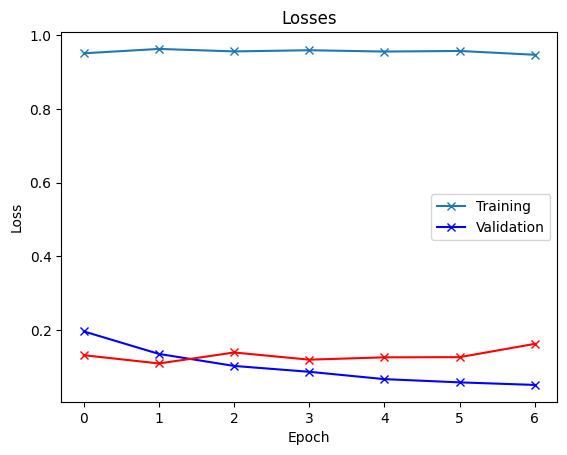

In [29]:
plot_accuracies(resnet_history)
plot_losses(resnet_history)


In [1]:
resnet_history = [
    {'train_loss': 0.1965, 'val_loss': 0.1320, 'val_acc': 0.9506},
    {'train_loss': 0.1355, 'val_loss': 0.1096, 'val_acc': 0.9624},
    {'train_loss': 0.1029, 'val_loss': 0.1394, 'val_acc': 0.9557},
    {'train_loss': 0.0870, 'val_loss': 0.1199, 'val_acc': 0.9589},
    {'train_loss': 0.0671, 'val_loss': 0.1262, 'val_acc': 0.9553},
    {'train_loss': 0.0584, 'val_loss': 0.1267, 'val_acc': 0.9569},
    {'train_loss': 0.0514, 'val_loss': 0.1627, 'val_acc': 0.9466},
]


In [3]:
import matplotlib.pyplot as plt


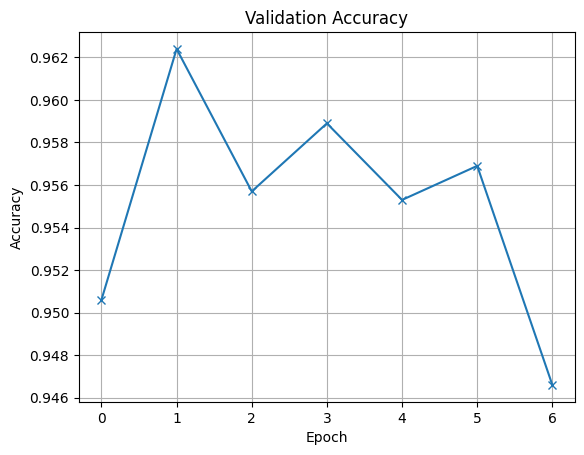

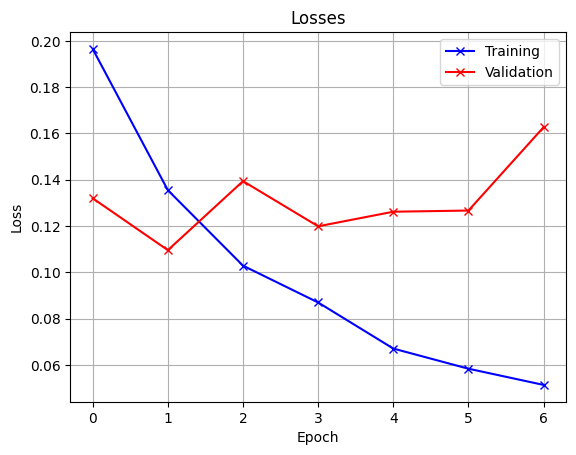

In [4]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.grid(True)
    plt.show()

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Losses')
    plt.grid(True)
    plt.show()

# Call them
plot_accuracies(resnet_history)
plot_losses(resnet_history)

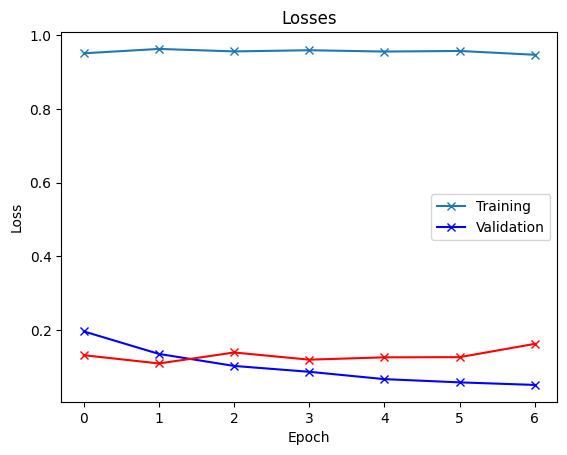

In [30]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Losses')

plot_accuracies(resnet_history)
plot_losses(resnet_history)


✅ STEP 5: Test Accuracy (ResNet-50)



In [37]:
correct = 0
total = 0

resnet_model.eval()
with torch.no_grad():
    for data in test_dl:
        images, labels = data
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('ResNet-50 Test Accuracy: {:.2f}%'.format(100 * correct / total))


ResNet-50 Test Accuracy: 94.46%


In [38]:
resnet_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data in test_dl:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('ResNet-50 Test Accuracy: {:.2f}%'.format(100 * correct / total))


ResNet-50 Test Accuracy: 94.80%


In [39]:
resnet_test_acc=100 * correct / total
print('ResNet-50 Test Accuracy: {:.2f}%'.format(resnet_test_acc))


ResNet-50 Test Accuracy: 94.80%


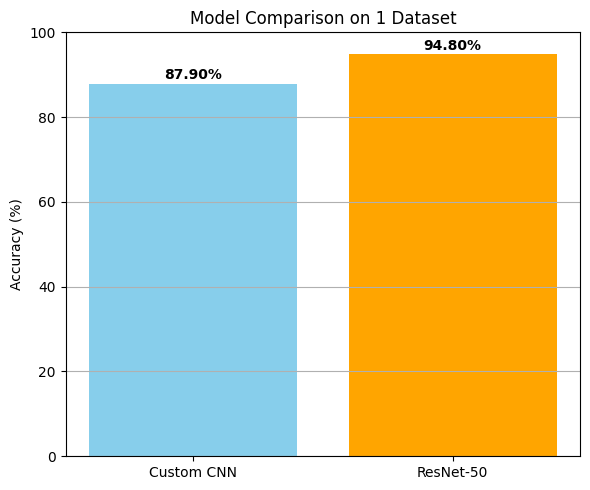

In [40]:
labels = ['Custom CNN', 'ResNet-50']
scores = [cnn_test_acc, resnet_test_acc]

plt.figure(figsize=(6, 5))
plt.bar(labels, scores, color=['skyblue', 'orange'])
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison on 1 Dataset")
for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


✅ STEP 6: Class-wise Accuracy for ResNet-50



In [41]:
class_correct = list(0. for _ in range(len(dataset.classes)))
class_total = list(0. for _ in range(len(dataset.classes)))

with torch.no_grad():
    for data in test_dl:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(len(dataset.classes)):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        print(f'Accuracy of {dataset.classes[i]:10s} : {acc:.2f}%')
    else:
        print(f'Accuracy of {dataset.classes[i]:10s} : N/A')


Accuracy of Organic    : 97.60%
Accuracy of Recyclable : 90.78%


✅ STEP 7: Predict a Single Image



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


Label: Recyclable | Predicted: Recyclable


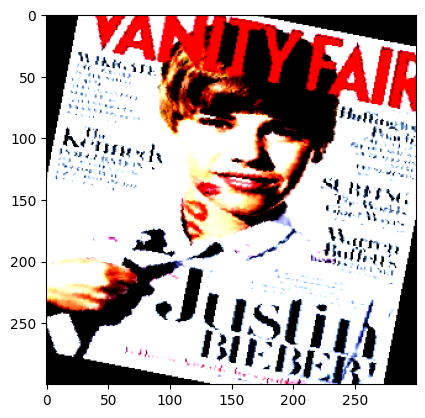

In [42]:
img, label = test_ds[25]
plt.imshow(img.permute(1, 2, 0))
print("Label:", dataset.classes[label], "| Predicted:", predict_image(img, resnet_model))


✅ STEP 8: Save ResNet-50 Model



✅ 1. Confusion Matrix (📦 sklearn)

Shows how well the model distinguishes between classes.



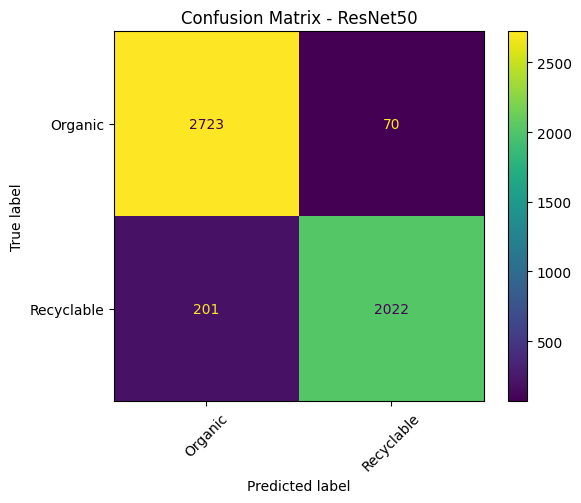

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

resnet_model.eval()
with torch.no_grad():
    for images, labels in test_dl:
        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
disp.plot(cmap='viridis', xticks_rotation=45)
plt.title("Confusion Matrix - ResNet50")
plt.show()


✅ 2. Per-Class Accuracy Bar Plot



C:\Users\Asus\AppData\Local\Temp\ipykernel_18460\2372718694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset.classes, y=accuracies, palette="cubehelix")


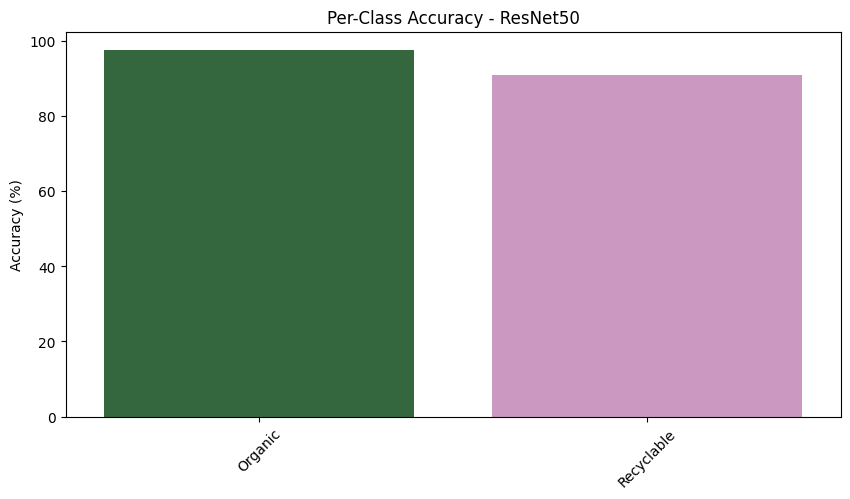

In [44]:
import seaborn as sns

accuracies = [100 * class_correct[i] / class_total[i] for i in range(len(dataset.classes))]

plt.figure(figsize=(10,5))
sns.barplot(x=dataset.classes, y=accuracies, palette="cubehelix")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy - ResNet50")
plt.xticks(rotation=45)
plt.show()


✅ 3. t-SNE / PCA Visualization (Visualizing Feature Space)

This helps you see how images from different classes are clustered in the feature space.



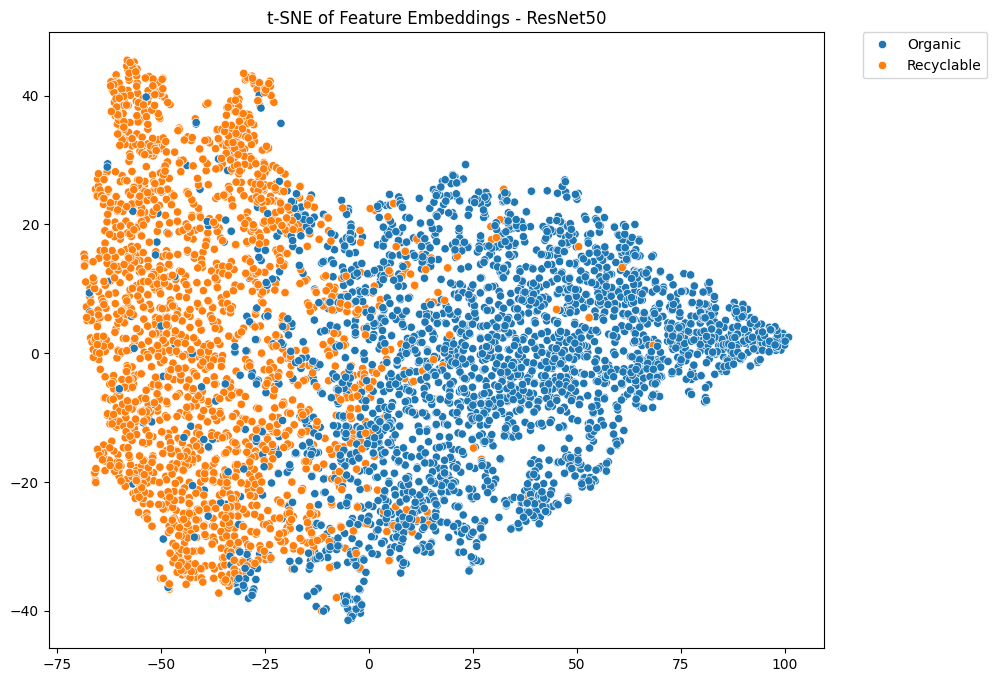

In [45]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

features = []
labels_list = []

resnet_model.eval()
with torch.no_grad():
    for images, labels in test_dl:
        feats = resnet_model.network.avgpool(resnet_model.network.layer4(resnet_model.network.layer3(resnet_model.network.layer2(resnet_model.network.layer1(resnet_model.network.relu(resnet_model.network.bn1(resnet_model.network.conv1(images))))))))
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

features = np.concatenate(features, axis=0)

# Reduce to 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_feats = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_feats[:,0], y=tsne_feats[:,1], hue=[dataset.classes[i] for i in labels_list], palette='tab10')
plt.title("t-SNE of Feature Embeddings - ResNet50")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()


✅ 1. Custom CNN Architecture


In [1]:
import torch
import torch.nn as nn

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 37 * 37, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

num_classes = 6  # Change this to match your dataset
model = ImprovedCNN(num_classes)
print("Custom CNN Architecture:")
print(model)


Custom CNN Architecture:
ImprovedCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.3, inplace=False)
    (14): Linear(in_features=175232, out_features=256, bias

✅ 2. ResNet-50 Architecture (Transfer Learning)


In [2]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 6  # Change this to match your dataset
resnet_model = models.resnet50(pretrained=True)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, num_classes)
print("ResNet-50 Architecture:")
print(resnet_model)


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [01:40<00:00, 1.02MB/s]


ResNet-50 Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_